<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 04 — Score candidates with the current zh smart-turn model

Run the current zh smart-turn checkpoint over every candidate clip
from `candidates.parquet` (notebook 03) and write
`candidates_scored.parquet` with two extra columns:

- `model_prob` — sigmoid output, `[0, 1]`.
- `model_pred` — `1` if `model_prob > threshold`, else `0`. The
  threshold comes from the checkpoint's `threshold.json` (the F1-best
  cut chosen on the held-out val split during training).

This becomes the second consensus signal in notebook 06 — alongside
the structural label (RAMC + VAD) and the LLM verdict (notebook 05).

Implementation notes:

- Audio is read **once per session**: we group candidates by
  `session_id`, load the full WAV with soundfile, then slice each
  clip out of the in-memory array. Re-decoding the same multi-hundred-
  MB WAV per row would dominate runtime.
- Each clip is **truncated to the trailing 8 s** (`chunk_length` in
  `preprocessor_config.json`) using the same
  `truncate_to_last_n_seconds` helper the training pipeline used —
  smart-turn looks at the *end* of an utterance, so left-padding /
  truncating from the front matches the train-time distribution.
- Inference is batched (`BATCH_SIZE = 32` on MPS / CUDA, 8 on CPU) so
  the per-call overhead of the Whisper encoder is amortized.

## Configure paths

In [1]:
from pathlib import Path

MINING_ROOT       = Path("../../datasets/smart-turn-zh-mining").resolve()
CANDIDATES_IN     = MINING_ROOT / "candidates.parquet"
CANDIDATES_OUT    = MINING_ROOT / "candidates_scored.parquet"
WAV_DIR           = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

CHECKPOINT_DIR    = Path("../../checkpoints/smart-turn-zh").resolve()

SAMPLE_RATE   = 16_000
CHUNK_LENGTH  = 8           # seconds; matches preprocessor_config.json

print(f"candidates : {CANDIDATES_IN.name}")
print(f"out        : {CANDIDATES_OUT.name}")
print(f"wavs       : {WAV_DIR.name}")
print(f"checkpoint : {CHECKPOINT_DIR.name}")
print("✅ paths configured")

candidates : candidates.parquet
out        : candidates_scored.parquet
wavs       : WAV
checkpoint : smart-turn-zh
✅ paths configured


## Load model + feature extractor

We import `SmartTurnModel` from `notebooks/smart-turn/smart_turn.py`
(the same class the training notebooks use), then load the trained
weights from `checkpoints/smart-turn-zh/`. The Whisper feature
extractor reads its config from the same directory — keeping
preprocessor and weights co-located prevents drift.

In [2]:
import json
import sys

import numpy as np
import torch
from transformers import WhisperFeatureExtractor

# Make ../smart-turn importable so we reuse SmartTurnModel +
# truncate_to_last_n_seconds rather than redefining them here.
SMART_TURN_PKG = (Path("../smart-turn")).resolve()
if str(SMART_TURN_PKG) not in sys.path:
    sys.path.insert(0, str(SMART_TURN_PKG))

from smart_turn import SmartTurnModel, pick_device, truncate_to_last_n_seconds  # noqa: E402

device = pick_device()

model = SmartTurnModel.from_pretrained(CHECKPOINT_DIR).to(device).eval()
fe = WhisperFeatureExtractor.from_pretrained(CHECKPOINT_DIR)

thr_path = CHECKPOINT_DIR / "threshold.json"
if thr_path.exists():
    THRESHOLD = float(json.loads(thr_path.read_text())["threshold"])
else:
    THRESHOLD = 0.5

print(f"device     : {device}")
print(f"params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"threshold  : {THRESHOLD:.3f}")
print("✅ model + feature extractor loaded")

Loading weights:   0%|          | 0/80 [00:00<?, ?it/s]

device     : mps
params     : 8,000,386
threshold  : 0.490
✅ model + feature extractor loaded


## Load candidates

Re-uses notebook 03's output. We sort by `session_id` so the
scoring loop reads each WAV exactly once.

In [3]:
import pandas as pd

cand = pd.read_parquet(CANDIDATES_IN)
cand = cand.sort_values(["session_id", "candidate_idx"]).reset_index(drop=True)

print(f"candidates : {len(cand):,}")
print(f"sessions   : {cand['session_id'].nunique()}")
print(f"label dist :")
print(cand["label"].value_counts().to_string())
print("✅ candidates loaded")

candidates : 33,943
sessions   : 349
label dist :
label
0    19959
1    13984
✅ candidates loaded


## Audio + feature helpers

`read_wav_16k_mono` mirrors notebook 02 — soundfile, no
torchaudio/torchcodec dependency. `clip_to_features` slices the
trailing 8 s ending at `clip_end_s`, then extracts log-mel features.

We end the slice at `clip_end_s` (not `clip_start_s + duration`)
because `truncate_to_last_n_seconds` left-pads if the clip is
shorter than 8 s, which is exactly what we want: the model decides
from the **last** moments of the clip.

In [4]:
import soundfile as sf

_audio_cache: dict[str, np.ndarray] = {}

def read_wav_16k_mono(wav_path: Path) -> np.ndarray:
    """Read a 16 kHz mono RAMC WAV as float32 in [-1, 1]."""
    arr, sr = sf.read(str(wav_path), dtype="float32", always_2d=False)
    if arr.ndim > 1:
        arr = arr.mean(axis=1)
    if sr != SAMPLE_RATE:
        import librosa
        arr = librosa.resample(arr, orig_sr=sr, target_sr=SAMPLE_RATE)
    return arr.astype(np.float32, copy=False)

def slice_clip(audio: np.ndarray, start_s: float, end_s: float) -> np.ndarray:
    """Return audio[start:end] clamped to bounds."""
    start = max(0, int(round(start_s * SAMPLE_RATE)))
    end   = min(len(audio), int(round(end_s   * SAMPLE_RATE)))
    if end <= start:
        return np.zeros(SAMPLE_RATE * CHUNK_LENGTH, dtype=np.float32)
    return audio[start:end]

def clip_to_input_features(audio: np.ndarray, start_s: float, end_s: float) -> torch.Tensor:
    clip = slice_clip(audio, start_s, end_s)
    clip = truncate_to_last_n_seconds(clip, SAMPLE_RATE, CHUNK_LENGTH)
    feats = fe(
        clip,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding="max_length",
        max_length=CHUNK_LENGTH * SAMPLE_RATE,
        truncation=True,
        do_normalize=True,
    )
    return feats["input_features"].squeeze(0)

print("✅ helpers ready")

✅ helpers ready


## Smoke test — score one batch

Sanity check the full path on the first 8 candidates before
committing to the full run. Confirms the WAV loads, the feature
extractor returns the expected shape, and the model produces
non-degenerate probabilities.

In [5]:
smoke = cand.head(8).copy()
first_session = smoke["session_id"].iloc[0]
audio = read_wav_16k_mono(WAV_DIR / f"{first_session}.wav")

feats = torch.stack([
    clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
    for row in smoke.itertuples()
    if row.session_id == first_session
]).to(device)

with torch.inference_mode():
    probs = model(input_features=feats)["logits"].cpu().numpy()

print(f"audio len   : {len(audio) / SAMPLE_RATE:.1f} s")
print(f"feat shape  : {tuple(feats.shape)}")
print(f"prob sample : {np.round(probs, 3).tolist()}")
assert feats.shape[1:] == (80, 800), feats.shape
assert probs.min() >= 0.0 and probs.max() <= 1.0
print("✅ smoke test passed")

audio len   : 843.4 s
feat shape  : (8, 80, 800)
prob sample : [0.36000001430511475, 0.5590000152587891, 0.35600000619888306, 0.5759999752044678, 0.4449999928474426, 0.36399999260902405, 0.39100000262260437, 0.6069999933242798]
✅ smoke test passed


## Score every candidate

Walk through `cand` session by session. For each session we:

1. Read the WAV once.
2. Build feature tensors for every candidate from that session.
3. Forward in `BATCH_SIZE`-sized chunks.
4. Drop the audio array before moving to the next session so memory
   stays flat.

Results land in `model_prob` / `model_pred` columns aligned to
`cand`'s row order.

In [6]:
from tqdm.auto import tqdm

BATCH_SIZE = 8 if device.type == "cpu" else 32

probs_out = np.full(len(cand), np.nan, dtype=np.float32)

session_groups = cand.groupby("session_id", sort=False)
pbar = tqdm(session_groups, total=session_groups.ngroups, desc="Sessions")

for session_id, group in pbar:
    wav_path = WAV_DIR / f"{session_id}.wav"
    if not wav_path.exists():
        pbar.write(f"  skip {session_id}: wav missing")
        continue
    audio = read_wav_16k_mono(wav_path)

    row_indices = group.index.to_numpy()
    feat_list = [
        clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
        for row in group.itertuples()
    ]

    for i in range(0, len(feat_list), BATCH_SIZE):
        batch = torch.stack(feat_list[i : i + BATCH_SIZE]).to(device)
        with torch.inference_mode():
            batch_probs = model(input_features=batch)["logits"].cpu().numpy()
        probs_out[row_indices[i : i + BATCH_SIZE]] = batch_probs

    del audio

n_scored = int(np.isfinite(probs_out).sum())
print(f"scored     : {n_scored:,} / {len(cand):,}")
print("✅ inference complete")

Sessions:   0%|          | 0/349 [00:00<?, ?it/s]

scored     : 33,943 / 33,943
✅ inference complete


## Save scored candidates

In [7]:
scored = cand.copy()
scored["model_prob"] = probs_out
scored["model_pred"] = (probs_out > THRESHOLD).astype(np.int8)
scored.loc[~np.isfinite(probs_out), "model_pred"] = -1  # sentinel: not scored

tmp_path = CANDIDATES_OUT.with_suffix(".parquet.tmp")
scored.to_parquet(tmp_path, index=False)
tmp_path.replace(CANDIDATES_OUT)

print(f"rows       : {len(scored):,}")
print(f"out        : {CANDIDATES_OUT.name} ({CANDIDATES_OUT.stat().st_size / 1e6:.1f} MB)")
print("✅ candidates_scored.parquet written")

rows       : 33,943
out        : candidates_scored.parquet (3.2 MB)
✅ candidates_scored.parquet written


## Calibration view

Two quick views over the model output:

1. **Agreement with the structural label** — how often does
   `model_pred == label`? Per-source breakdown tells us whether the
   model is more reliable on speaker-change EOTs vs intra-utterance
   continuations.
2. **Probability histogram by label** — the further the two
   distributions are pulled apart, the more useful the model signal
   is in the consensus router (notebook 06).

These are *diagnostic*, not pass/fail — the consensus pipeline is
designed to tolerate disagreement (route to human review) rather
than demand model perfection.

In [8]:
scored_ok = scored[scored["model_pred"] != -1]

print("agreement with structural label:")
for source, sub in scored_ok.groupby("source"):
    agree = (sub["model_pred"] == sub["label"]).mean()
    print(f"  {source:22s} {len(sub):>6,}  agree={agree:.3f}")

print("\nprob distribution by structural label:")
for lbl, sub in scored_ok.groupby("label"):
    p = sub["model_prob"].to_numpy()
    qs = np.quantile(p, [0.10, 0.25, 0.50, 0.75, 0.90])
    print(
        f"  label={lbl} n={len(sub):>6,}  "
        f"p10={qs[0]:.2f}  p25={qs[1]:.2f}  p50={qs[2]:.2f}  "
        f"p75={qs[3]:.2f}  p90={qs[4]:.2f}"
    )
print("✅ calibration summary printed")

agreement with structural label:
  intra_utterance_cut    19,959  agree=0.569
  speaker_change         13,984  agree=0.757

prob distribution by structural label:
  label=0 n=19,959  p10=0.36  p25=0.38  p50=0.46  p75=0.56  p90=0.60
  label=1 n=13,984  p10=0.40  p25=0.49  p50=0.57  p75=0.61  p90=0.62
✅ calibration summary printed


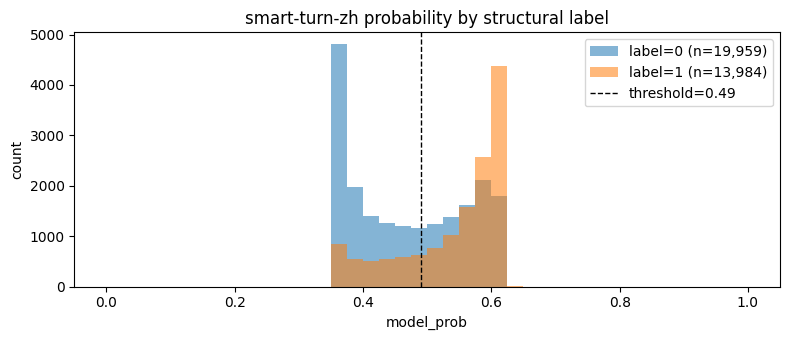

✅ histogram drawn


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, 1, 41)
for lbl, color in [(0, "tab:blue"), (1, "tab:orange")]:
    sub = scored_ok[scored_ok["label"] == lbl]["model_prob"]
    ax.hist(sub, bins=bins, alpha=0.55, label=f"label={lbl} (n={len(sub):,})", color=color)
ax.axvline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("model_prob")
ax.set_ylabel("count")
ax.set_title("smart-turn-zh probability by structural label")
ax.legend()
fig.tight_layout()
plt.show()
print("✅ histogram drawn")